## For the global training - visualize the normalized data 


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.cio as cio
import matplotlib.pyplot as plt
import nibabel as nb
import Functional_Fusion.plot as ffpl 

## Cortical data after scaling and combination 

In [3]:
traindata = 'MdWfIbDeHtNiSoScLa'
data_cifti = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cortex.pscalar.nii")
X = data_cifti.get_fdata()

In [4]:
row_axis = data_cifti.header.get_axis(0)      # ScalarAxis / LabelAxis / SeriesAxis
names = list(row_axis.name)
parts = [s.split('_') for s in names]
D=pd.DataFrame(parts,columns=['Dataset','task','cond','half','empty'])
# Find the rows which are the first for each dataset
first = np.where(~D.Dataset.duplicated())[0]

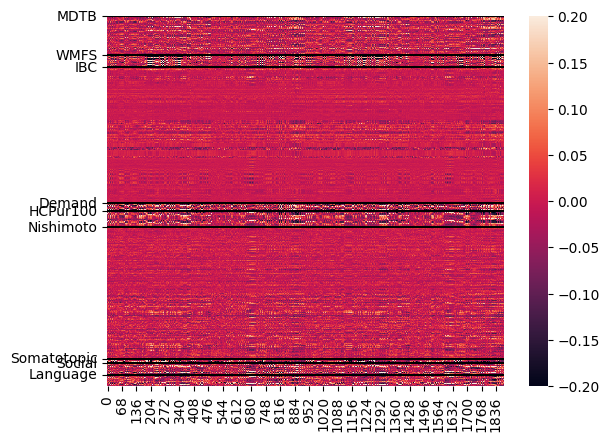

In [5]:
sns.heatmap(X,vmin=-0.2,vmax=0.2)
ax=plt.gca()
ax.set_yticks(first)
ax.set_yticklabels(D.Dataset.iloc[first])
for f in first:
    plt.axhline(f,color='k')

In [6]:
D['SS_cortex']= (X**2).sum(axis=1)
D['S_cortex']= X.sum(axis=1)
pd.pivot_table(D,index='Dataset',values='SS_cortex',aggfunc='sum')

,SS_cortex
Dataset,
Demand,668.266886
HCPur100,581.485173
IBC,412.636048
Language,501.542375
MDTB,640.228380
Nishimoto,641.098735
Social,501.533960
Somatotopic,1186.918844
WMFS,760.627146


In [7]:
# Plot cortical map 
label_fs = [gl.atlas_dir + f"/tpl-fs32k/Icosahedron1002.{hemi}.label.gii" for hemi in ["L", "R"]]
cifti_img = cio.model_to_cifti((X**2).sum(axis=0),src_roi = label_fs)
S=cifti_img.get_fdata()
S.shape

/Users/jdiedrichsen/miniconda3/lib/python3.11/site-packages/nibabel/cifti2/cifti2.py:1492: UserWarning: Dataobj shape (1876,) does not match shape expected from CIFTI-2 header (1876, 1876)
  warn(


(1876,)

## Cerebellar data after scaling and combination

In [8]:
traindata = 'MdWfIbDeHtNiSoScLa'
data_ciftiC = nb.load(gl.conn_dir + f"/maps/{traindata}_data_cerebellum.dscalar.nii")
Y = data_ciftiC.get_fdata()

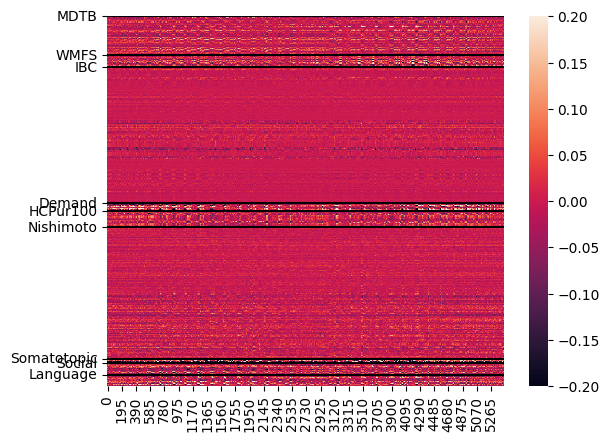

In [9]:
sns.heatmap(Y,vmin=-0.2,vmax=0.2)
ax=plt.gca()
ax.set_yticks(first)
ax.set_yticklabels(D.Dataset.iloc[first])
for f in first:
    plt.axhline(f,color='k')

In [10]:
D['SS_cereb']= (Y**2).sum(axis=1)
D['S_cereb']= Y.sum(axis=1)
pd.pivot_table(D,index='Dataset',values='SS_cereb',aggfunc='sum')

,SS_cereb
Dataset,
Demand,1389.650693
HCPur100,637.987797
IBC,786.145697
Language,1176.057258
MDTB,1075.660350
Nishimoto,1296.493551
Social,698.456164
Somatotopic,2925.432926
WMFS,1365.206803


<Axes: >

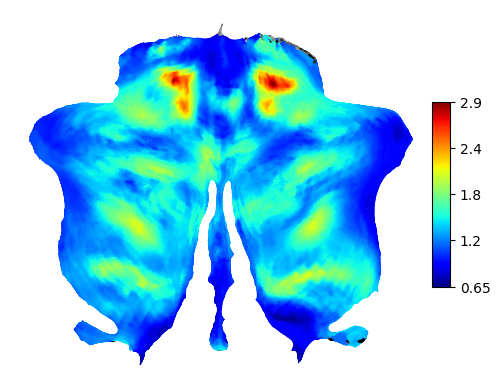

In [ ]:
## Plot overall length of vector per cerebellar voxel
vector_length = np.sqrt((Y**2).sum(axis=0))
ffpl.plot_cerebellum(vector_length,colorbar=True)

In [18]:
## Quick check on scaling 
A = np.random.normal(0,1,(20,80))*5
B = np.random.normal(0,1,(5,80))
SS = []
SS.append(rm.std_data(A,'parcel'))
SS.append(rm.std_data(A,'global'))
SS.append(rm.std_data(B,'parcel'))
SS.append(rm.std_data(B,'global'))
for i in range(4):
    print(f'{(SS[i]**2).sum()}')


80.0
80.0
80.0
80.0
